# Importing libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
from matplotlib.collections import PatchCollection
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr
from scipy.stats import norm
import seaborn as sns
import pandas as pd
import numpy as np
import os
directory = os.getcwd()
parent_directory = os.path.dirname(directory)
%load_ext rpy2.ipython

In [5]:
%%R  -w 8 -h 3 #--units in -r 200
##installing packages and setting options for the plots in R

# {r settings, echo=F, message=F, error=F}
knitr::opts_chunk$set(echo = F)
if (!require("pacman")) install.packages("pacman")
pacman::p_load(ggplot2, patchwork, cowplot, tidyverse, devtools, ggrepel, ggh4x, officer, rvg, svglite, lme4, lmerTest, install = T)

# # Required on the first run, comment afterward?
devtools::install_github("BlakeRMills/MoMAColors")
library(MoMAColors)

theme_set(theme_cowplot() +
          theme(text = element_text(size=9),
                axis.text = element_text(size=9),
                panel.grid.major.x = element_blank() ,
                panel.grid.major.y = element_line( linewidth=.1, color="black")))

Using GitHub PAT from the git credential store.
Skipping install of 'MoMAColors' from a github remote, the SHA1 (6f5d75de) has not changed since last install.
  Use `force = TRUE` to force installation


In [3]:
folder = 'language_shapes'
files = os.listdir(folder)
dataframes = []

for file in files:
    df = pd.read_csv(os.path.join(folder, file))
    dataframes.append(df)

raw = pd.concat(dataframes, ignore_index=True)
filtered_raw = raw[raw['trial_type'] == 'oddball-grid-img'].copy()
greys = pd.read_csv('language_shapes_greys.csv')

filtered_raw = pd.merge(filtered_raw.copy(), greys)
averaged_df = filtered_raw.groupby(['reference','distractors']).agg({'choice_time':'mean', 'greys':'mean'}).reset_index()
averaged_df = averaged_df[~averaged_df['reference'].str.startswith('./stimuli_train', na=False)]

In [4]:
def get_rs(dists, averaged_df=averaged_df):
    cumulative_distraction = []
    choice_times = []
    closest_dists = []
    greys = []
    refs = []
    costs = []
    for i in range(len(averaged_df)):
        distractors = averaged_df.iloc[i].distractors.split(',')
        cost = int((averaged_df.iloc[i].reference.split('/')[2]).split('-')[1])
        ref = averaged_df.iloc[i].reference.split('/')[3].split('.png')[0]
        others = [name.split('/')[3].split('.png')[0] for name in distractors]
        others.remove(ref)
        distances = dists.loc[ref, others].values
        if 0 in distances:
            print(distractors)
            break
        difficulty = np.sum(1/np.array(distances))
        # print(dists)
        # print(ref)
        # print(distractors)
        closest_dists.append(1/np.min(distances))
        costs.append(cost)
        cumulative_distraction.append(difficulty)
        choice_times.append(averaged_df.iloc[i].choice_time)
        greys.append(averaged_df.iloc[i].greys)
        refs.append(ref)
        results_dict = {
            'reference':refs,
            'choice_time':choice_times,
            'distances':closest_dists,
            'costs':costs,
            'cumulative_distraction': cumulative_distraction,
            'grey_level':greys
        }

    results = pd.DataFrame(results_dict)
    results_grouped = results.groupby('reference').mean()

    X1 = results_grouped['grey_level'].to_numpy()
    # .fit_transform(results_grouped[['grey_level']])
    X2 = results_grouped['cumulative_distraction']
    X2 = X2.apply(pd.to_numeric, errors='coerce').to_numpy()

    # .fit_transform(results_grouped[['cumulative_distraction']])
    X3 = results_grouped['distances']
    X3 = X3.apply(pd.to_numeric, errors='coerce').to_numpy()
    X4 = results_grouped['costs']
    X4 = X4.apply(pd.to_numeric, errors='coerce').to_numpy()

    # .fit_transform(results_grouped[['distances']])
    y1 = results_grouped['choice_time'].to_numpy()
    # .fit_transform(results_grouped['choice_time'])

    # Get residuals from choice time by grey level
    lin_model1 = sm.OLS(y1, sm.add_constant(X1)).fit()
    res = lin_model1.resid
 

    # Fit the models on the residuals
    # lin_model2 = sm.OLS(res, sm.add_constant(X2)).fit()
    # lin_model3 = sm.OLS(res, sm.add_constant(X3)).fit()
    # lin_model4 = sm.OLS(res, sm.add_constant(X4)).fit()

    r_distraction, _ = pearsonr(X2, res)
    r_distance, _ = pearsonr(X3, res)
    r_MDL, _ = pearsonr(X4, res)

    return r_distraction, r_distance, r_MDL



# First plots

In [7]:
def plot_preds(dists):
    cumulative_distraction = []
    choice_times = []
    closest_dists = []
    greys = []
    refs = []
    costs = []
    for i in range(len(averaged_df)):
        distractors = averaged_df.iloc[i].distractors.split(',')
        cost = int((averaged_df.iloc[i].reference.split('/')[2]).split('-')[1])
        ref = averaged_df.iloc[i].reference.split('/')[3].split('.png')[0]
        others = [name.split('/')[3].split('.png')[0] for name in distractors]
        others.remove(ref)
        distances = dists.loc[ref, others].values
        if np.any(pd.isna(distances)):
            print(f"[NaN in distances] ref={ref}, others={others}, distances={distances}")
        if np.min(distances) == 0:
            print(f"[Zero distance] ref={ref}, distances={distances}")
        
        difficulty = np.sum(1/np.array(distances))
      
        closest_dists.append(1/np.min(distances))

        costs.append(cost)
        cumulative_distraction.append(difficulty)
        choice_times.append(averaged_df.iloc[i].choice_time)
        greys.append(averaged_df.iloc[i].greys)
        refs.append(ref)
        results_dict = {
            'reference':refs,
            'choice_time':choice_times,
            'distances':closest_dists,
            'costs':costs,
            'cumulative_distraction': cumulative_distraction,
            'grey_level':greys
        }

    results = pd.DataFrame(results_dict)

    results_grouped = results.groupby('reference').mean()


    X1 = results_grouped['grey_level'].to_numpy()
    X2 = results_grouped['cumulative_distraction']
    X2 = X2.apply(pd.to_numeric, errors='coerce').to_numpy()

    X3 = results_grouped['distances']
    X3 = X3.apply(pd.to_numeric, errors='coerce').to_numpy()
    X4 = results_grouped['costs']
    X4 = X4.apply(pd.to_numeric, errors='coerce').to_numpy()

    y1 = results_grouped['choice_time'].to_numpy()

    # Get residuals from choice time by grey level
    lin_model1 = sm.OLS(y1, sm.add_constant(X1)).fit()
    res = lin_model1.resid

    results_grouped['residuals'] = res
    if results_grouped['residuals'].isna().any():
        print("\n[NaN in residuals!]")
        print(results_grouped[['grey_level', 'choice_time', 'residuals']])
        
    plot1_data = results_grouped.groupby('costs')['residuals'].agg(['mean', 'sem']).reset_index()
    plot1_data.columns = ['costs', 'mean_residual', 'sem_residual']


    results_grouped['cumulative_distraction_bin'] = pd.qcut(
        results_grouped['cumulative_distraction'],
        q=12,
    )
    print("\n[Check after binning]")
    print(results_grouped.isna().sum(), "rows with NaN bin assignment")
    print(results_grouped[results_grouped['cumulative_distraction_bin'].isna()])
    print(results_grouped['cumulative_distraction'].min(), results_grouped['cumulative_distraction'].max())
    # print(results_grouped)
    results_grouped = results_grouped.dropna(subset=['residuals'])

    plot2_data = results_grouped.groupby('cumulative_distraction_bin')['residuals'].agg(['mean', 'sem']).reset_index()
    print(plot2_data)
    plot2_data.columns = ['cumulative_distraction_bin', 'mean_residual', 'sem_residual']
    plot2_data['bin_center'] = plot2_data['cumulative_distraction_bin'].apply(lambda x: x.mid)

    return plot1_data, plot2_data
    

In [8]:
dists = pd.read_csv('RDMs/vit_giant_patch14_clip_224.laion2b/layer_24', index_col=0)
temp1, temp2 = plot_preds(dists)
temp2.drop('cumulative_distraction_bin', axis=1, inplace=True)
temp2.bin_center = temp2.bin_center.apply(lambda x: float(x))
temp1.to_csv('temp1.csv')
temp2.to_csv('temp2.csv')


[Check after binning]
choice_time                   0
distances                     0
costs                         0
cumulative_distraction        0
grey_level                    0
residuals                     0
cumulative_distraction_bin    0
dtype: int64 rows with NaN bin assignment
Empty DataFrame
Columns: [choice_time, distances, costs, cumulative_distraction, grey_level, residuals, cumulative_distraction_bin]
Index: []
0.05679211818644872 0.08166804695877367
   cumulative_distraction_bin        mean         sem
0            (0.0558, 0.0614] -290.649566  120.299648
1            (0.0614, 0.0637]  -51.010824  125.724276
2            (0.0637, 0.0647]  -90.790804   71.371338
3            (0.0647, 0.0657] -156.495540  101.730738
4            (0.0657, 0.0669]  -92.882428   74.311062
5             (0.0669, 0.068] -125.582908   59.126467
6             (0.068, 0.0688] -129.737841  109.011702
7            (0.0688, 0.0709]  254.062058  159.299120
8            (0.0709, 0.0717]  204.724288  

/var/folders/yr/1hvrtjdn3hzc_7rf_6kpdl69v063g3/T/ipykernel_10823/1492575493.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot2_data = results_grouped.groupby('cumulative_distraction_bin')['residuals'].agg(['mean', 'sem']).reset_index()


Cannot find directory 'plots'.
ℹ Would you like to create a new directory?

1: Yes
2: No

✔ Created directory: 'plots'.
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In addition: Warning messages:
1: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: `guide_axis_manual()` was deprecated in ggh4x 0.3.0.
ℹ Please use `legendry::guide_axis_base()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The S3 guide system was deprecated in ggplot2 3.5.0.
ℹ It has been replaced by a ggproto system that can be extended.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
4: `is.ggproto()` was deprecated in ggplot2 3.5.2.
ℹ Please use `is_ggproto()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


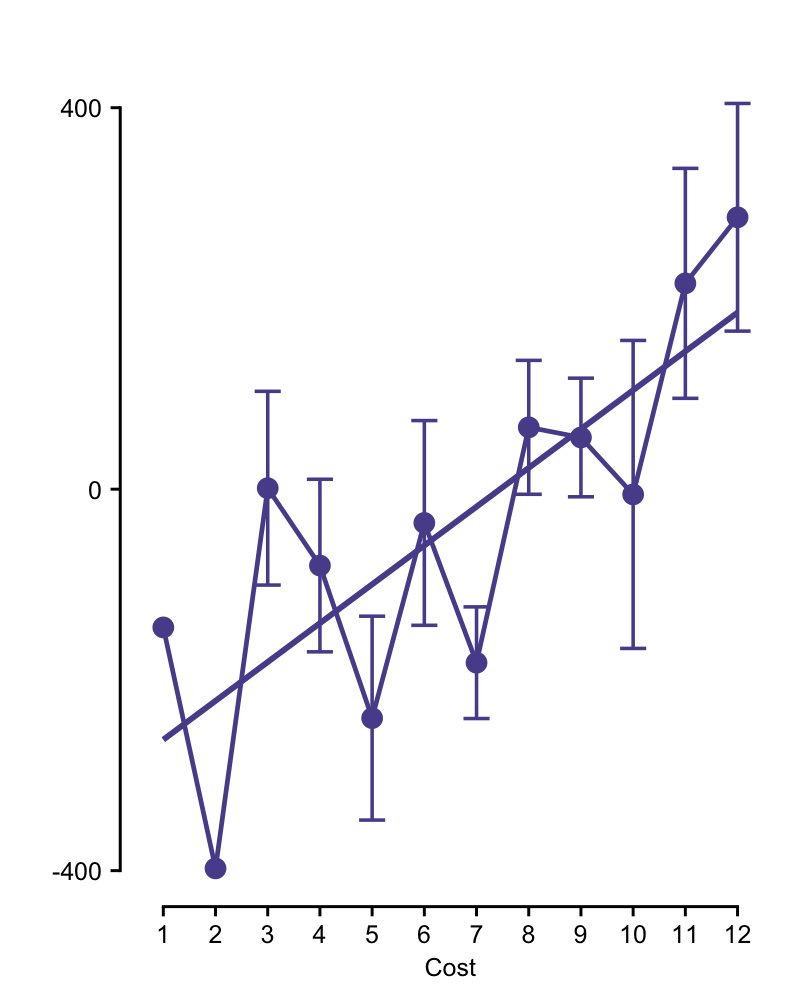

In [9]:
%%R -w 4 -h 5 --units in -r 200 

data <- read.csv('temp1.csv')

c1 = '#5A509B'
p <- ggplot(data, aes(x = costs, y = mean_residual)) +
  # Add the line connecting the points
  geom_line(color = c1, size = 0.8) +
  # Add the points
  geom_point(color = c1, size = 3, shape = 19) +
  # Add error bars
  geom_errorbar(aes(ymin = mean_residual - sem_residual,
                    ymax = mean_residual + sem_residual),
                width = 0.5, # Controls the width of the error bar caps
                size = 0.6,  # Controls the thickness of the error bars
                color = c1) +
  # Set labels and title
  labs(
    x = "Cost",
    y = "",
    title = ""
  ) +

  geom_smooth(method = "lm", se = FALSE, color = c1) +
  theme(
    panel.grid.major = element_blank(), # Remove major grid lines
    panel.grid.minor = element_blank(), # Remove minor grid lines
    panel.background = element_blank(), 
    panel.grid.major.y = element_blank(),

  ) +

guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=12, breaks=seq(1, 12,1)),
        y = guide_axis_manual(trunc_lower=-400, trunc_upper=400, breaks=c(-400,0,400)))

ggsave("plots/reg_MDL_choice_time.svg", p, device='svg',width = 3, height = 4, units = "in")
p

    X mean_residual sem_residual bin_center
1   0    -290.64957    120.29965    0.05860
2   1     -51.01082    125.72428    0.06255
3   2     -90.79080     71.37134    0.06420
4   3    -156.49554    101.73074    0.06520
5   4     -92.88243     74.31106    0.06630
6   5    -125.58291     59.12647    0.06745
7   6    -129.73784    109.01170    0.06840
8   7     254.06206    159.29912    0.06985
9   8     204.72429    115.85363    0.07130
10  9     159.55395    147.45567    0.07265
11 10     216.56381    104.75147    0.07435
12 11     140.56960    113.00009    0.07840
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


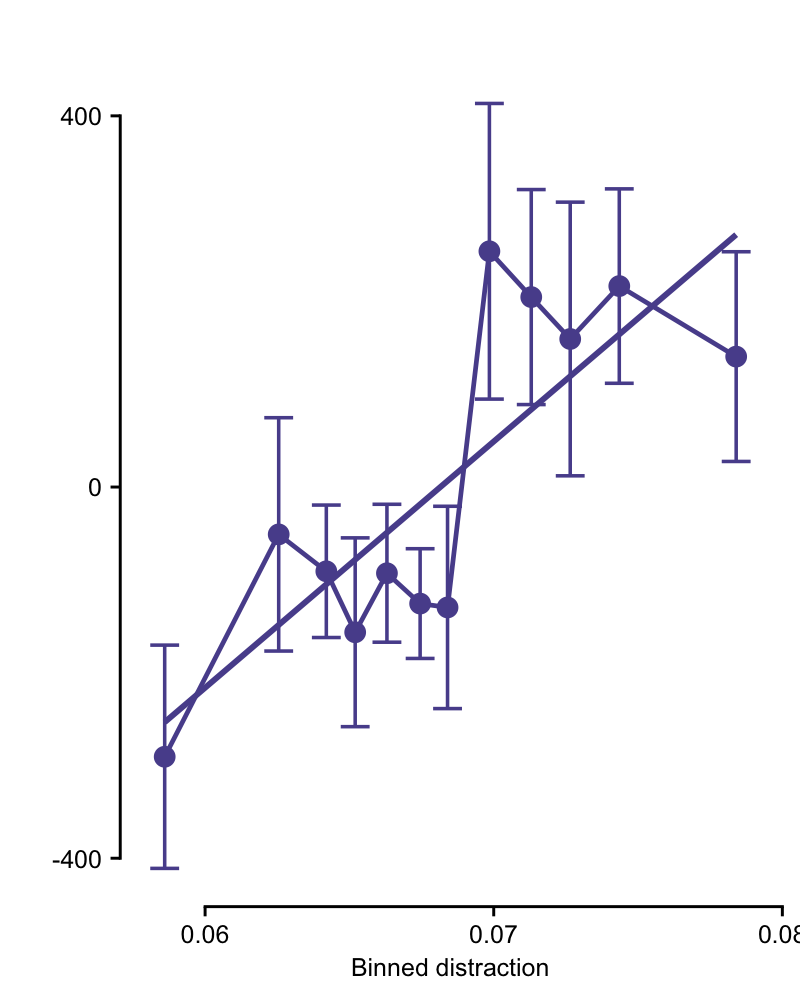

In [10]:
%%R -w 4 -h 5 --units in -r 200 

data <- read.csv('temp2.csv')
print(data)
c1 = '#5A509B'
p <- ggplot(data, aes(x = bin_center, y = mean_residual)) +
  # Add the line connecting the points
  geom_line(color = c1, size = 0.8) +
  # Add the points
  geom_point(color = c1, size = 3, shape = 19) +
  # Add error bars
  geom_errorbar(aes(ymin = mean_residual - sem_residual,
                    ymax = mean_residual + sem_residual),
                width = 0.001, # Controls the width of the error bar caps
                size = 0.6,  # Controls the thickness of the error bars
                color = c1) +
  # Set labels and title
  labs(
    x = "Binned distraction",
    y = "",
    title = ""
  ) +
  geom_smooth(method = "lm", se = FALSE, color = c1) +

  theme(
    panel.grid.major = element_blank(), # Remove major grid lines
    panel.grid.minor = element_blank(), # Remove minor grid lines
    panel.background = element_blank(), 
    panel.grid.major.y = element_blank(),

  ) +

guides(x = guide_axis_manual(trunc_lower=0.06, trunc_upper=0.08, breaks=seq(0.06,0.08,0.01)),
        y = guide_axis_manual(trunc_lower=-400, trunc_upper=400, breaks=c(-400,0,400)))

ggsave("plots/reg_inverse_dist_clip_choice_time.svg", p, device='svg',width = 3, height = 4, units = "in")

p

In [11]:
dists = pd.read_csv('RDMs/dinov3_base/layer_13', index_col=0)
temp1, temp2 = plot_preds(dists)
temp2.drop('cumulative_distraction_bin', axis=1, inplace=True)
temp2.bin_center = temp2.bin_center.apply(lambda x: float(x))
temp1.to_csv('temp1.csv')
temp2.to_csv('temp2.csv')


[Check after binning]
choice_time                   0
distances                     0
costs                         0
cumulative_distraction        0
grey_level                    0
residuals                     0
cumulative_distraction_bin    0
dtype: int64 rows with NaN bin assignment
Empty DataFrame
Columns: [choice_time, distances, costs, cumulative_distraction, grey_level, residuals, cumulative_distraction_bin]
Index: []
0.03604592177137348 0.07712591910580188
        cumulative_distraction_bin        mean         sem
0   (0.034999999999999996, 0.0402] -285.300119  110.684010
1                 (0.0402, 0.0429] -113.800231   81.375417
2                 (0.0429, 0.0446] -213.496780   71.536195
3                  (0.0446, 0.045] -113.839121   58.061865
4                  (0.045, 0.0464]  -95.571451   81.193601
5                 (0.0464, 0.0478]   86.355174  117.622448
6                 (0.0478, 0.0496]  102.707249   99.076058
7                 (0.0496, 0.0503]    7.368216  188.83300

/var/folders/yr/1hvrtjdn3hzc_7rf_6kpdl69v063g3/T/ipykernel_10823/1492575493.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot2_data = results_grouped.groupby('cumulative_distraction_bin')['residuals'].agg(['mean', 'sem']).reset_index()


    X mean_residual sem_residual bin_center
1   0   -285.300119    110.68401    0.03760
2   1   -113.800231     81.37542    0.04155
3   2   -213.496780     71.53619    0.04375
4   3   -113.839121     58.06186    0.04480
5   4    -95.571451     81.19360    0.04570
6   5     86.355174    117.62245    0.04710
7   6    102.707249     99.07606    0.04870
8   7      7.368216    188.83301    0.04995
9   8    -31.401754    108.95709    0.05140
10  9     45.787008    120.68668    0.05450
11 10    222.819740    141.70651    0.05920
12 11    345.719901    110.97434    0.06950
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


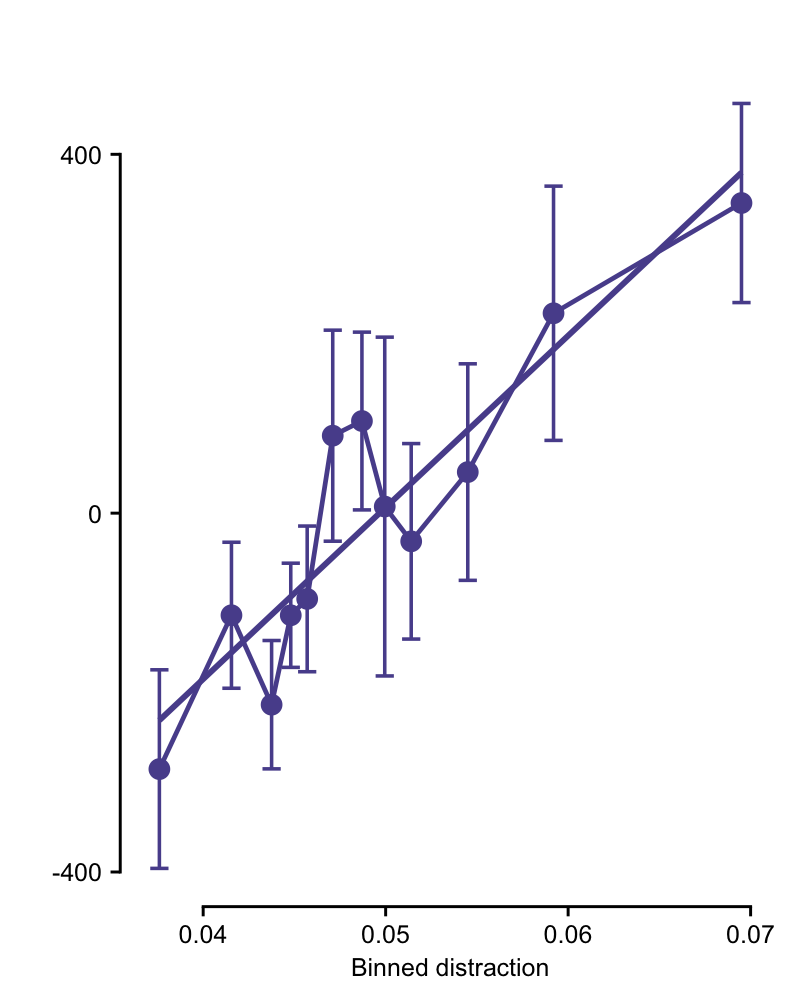

In [12]:
%%R -w 4 -h 5 --units in -r 200 

data <- read.csv('temp2.csv')
print(data)
c1 = '#5A509B'
p <- ggplot(data, aes(x = bin_center, y = mean_residual)) +
  # Add the line connecting the points
  geom_line(color = c1, size = 0.8) +
  # Add the points
  geom_point(color = c1, size = 3, shape = 19) +
  # Add error bars
  geom_errorbar(aes(ymin = mean_residual - sem_residual,
                    ymax = mean_residual + sem_residual),
                width = 0.001, # Controls the width of the error bar caps
                size = 0.6,  # Controls the thickness of the error bars
                color = c1) +
  # Set labels and title
  labs(
    x = "Binned distraction",
    y = "",
    title = ""
  ) +
  geom_smooth(method = "lm", se = FALSE, color = c1) +

  theme(
    panel.grid.major = element_blank(), # Remove major grid lines
    panel.grid.minor = element_blank(), # Remove minor grid lines
    panel.background = element_blank(), 
    panel.grid.major.y = element_blank(),

  ) +

guides(x = guide_axis_manual(trunc_lower=0.04, trunc_upper=0.07, breaks=c(0.04, 0.05, 0.06, 0.07)),
        y = guide_axis_manual(trunc_lower=-400, trunc_upper=400, breaks=c(-400,0,400)))

ggsave("plots/reg_inverse_dist_dinov3_choice_time.svg", p, device='svg',width = 3, height = 4, units = "in")

p

# With best layer

In [ ]:
base_dir = os.path.join(directory, 'RDMs')

r_distractions = []
r_distances = []
count_last_best = 0
count_all = 0
names = []
best_layers = []
for model in os.listdir(base_dir): 
    model_path = os.path.join(base_dir, model)
    print(model)
    if os.path.isdir(model_path):  # Ensure it's a folder
        # Find all files that match "layer_n"
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]
        layer_nums = {f: int(f.split("_")[1]) for f in layer_files}
        last_layer = max(layer_nums, key=layer_nums.get)
        layer_files = sorted(layer_files, key=lambda x: int(x.split("_")[1]))

        max_corr = 0
        best_layer = None
        for layer in layer_files:            
            file_path = os.path.join(model_path, layer)

            dists = pd.read_csv(file_path, index_col=0)
            r_distraction, r_distance, r_MDL = get_rs(dists=dists)
            if r_distraction >= max_corr:   
                max_corr = r_distraction
                best_layer = layer
        r_distractions.append(max_corr)
        r_distances.append(r_distance)
        names.append(model)
        
        # Update counts
        count_all += 1
        if best_layer == last_layer:
            count_last_best += 1
        if not best_layer == last_layer:
            print(model)
            print(best_layer)
        best_layers.append(best_layer)
print(r_MDL)


convnext_tiny.fb_in22k
vit_tiny_in22k
vit_tiny_in22k
layer_12
convnext_tiny.fb_in1k
convnext_tiny.fb_in1k
layer_1
dinov3_small
dinov3_convnext_tiny
dinov3_convnext_tiny
layer_4
vit_huge_in22k
vit_huge_in22k
layer_32
convnext_large.fb_in22k
dinov3_huge
cornet
cornet
layer_2
convnext_small.fb_in1k
vit_large_in22k
vit_base_in22k
vit_base_patch16_clip_224.laion2b
vit_base_patch16_clip_224.laion2b
layer_8
vit_base_patch16_clip_224.openai
vit_base_patch16_clip_224.openai
layer_9
convnext_base.fb_in22k
convnext_base.fb_in1k
dinov3_large
vit_huge_patch14_clip_224.laion2b
vit_huge_patch14_clip_224.laion2b
layer_19
vit_small_patch16_224.augreg_in1k
vit_small_patch16_224.augreg_in1k
layer_8
dino_base
dinov3_base
vit_giant_patch14_clip_224.laion2b
vit_giant_patch14_clip_224.laion2b
layer_24
resnet18.a1_in1k
resnet18.a1_in1k
layer_3
dinov3_convnext_base
resnet101_clip.openai
resnet50.a1_in1k
resnet50.a1_in1k
layer_3
resnet101.a1_in1k
resnet101.a1_in1k
layer_3
convnext_small.fb_in22k
vit_large_patch

NameError: name 'df_rs' is not defined

In [16]:
df_rs = pd.DataFrame({
    'model': names,
    'r_distance': r_distances,
    'r_distraction': r_distractions,
    'best_layer': best_layers
})
df_rs = df_rs.sort_values(by='r_distraction', ascending=True)
df_rs.to_csv('best_layers.csv')
            

In [17]:
proportion_last_best = count_last_best / count_all if count_all > 0 else 0
print(f"Proportion of models where best layer is last: {proportion_last_best:.2f}")

Proportion of models where best layer is last: 0.58


In [20]:
metadata = pd.read_csv(parent_directory +'/utils/metadata_models.csv')
metadata_clean = metadata.transpose().reset_index()
metadata_clean.dropna(inplace=True)
metadata_clean.columns = ['model', 'number_parameters', 'train_set']
def clean_number(n):
    num = int(n)//1000000
    return f'{num}M'
dict_sizes = {'in1k' : int(1281167),
              'in22k' :int(14197122),
              'openai-400m' : int(400000000),
              'LVD-142M' : int(142000000),
              'LVD-1689M' : int(1700000000),
              'laion2b': int(2000000000),

              }

df_plot = pd.merge(metadata_clean, df_rs, how='outer')
df_plot.columns = ['model', 'number_parameters', 'train_set', 'r_distance','r_distraction', 'layer']
df_plot['train_set_size'] = df_plot.train_set.apply(lambda x: dict_sizes[x] if pd.notna(x) else None)
df_plot = df_plot.dropna()
df_plot['number_parameters'] = df_plot.number_parameters.apply(lambda x: int(x))
## Compute a function of the number of parameters for the plot, such that the smallest points are visible and the biggests don't take the whole screen
chosen_power = 2/3 

df_plot['power_number_parameters'] = np.power(df_plot['number_parameters'], chosen_power)
df_plot['power_number_parameters'] = np.where(df_plot['number_parameters'] > 5e9, df_plot['power_number_parameters'] / 1.5, df_plot['power_number_parameters'])

# Compute the log of the number of parameters
df_plot['log_number_parameters'] = np.log10(df_plot['number_parameters'])
def classify_backbone(name):
    if 'convnext' in name:
        return "cnn"
    elif name.startswith(("vit", "dino", "clip")):
        return "vit"
    else:
        return "cnn"

df_plot["backbone"] = df_plot['model'].apply(classify_backbone)
conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
df_plot.to_csv('all_cors.csv',index=False)

In [22]:
#### adding the MDL to networks
def get_rs_2(dists, averaged_df=averaged_df):
    cumulative_distraction = []
    choice_times = []
    closest_dists = []
    greys = []
    refs = []
    costs = []
    for i in range(len(averaged_df)):
        distractors = averaged_df.iloc[i].distractors.split(',')
        cost = int((averaged_df.iloc[i].reference.split('/')[2]).split('-')[1])
        ref = averaged_df.iloc[i].reference.split('/')[3].split('.png')[0]
        others = [name.split('/')[3].split('.png')[0] for name in distractors]
        others.remove(ref)
        distances = dists.loc[ref, others].values
        if 0 in distances:
            print(distractors)
            break
        difficulty = np.sum(1/np.array(distances))
        # print(dists)
        # print(ref)
        # print(distractors)
        closest_dists.append(1/np.min(distances))
        costs.append(cost)
        cumulative_distraction.append(difficulty)
        choice_times.append(averaged_df.iloc[i].choice_time)
        greys.append(averaged_df.iloc[i].greys)
        refs.append(ref)
        results_dict = {
            'reference':refs,
            'choice_time':choice_times,
            'distances':closest_dists,
            'costs':costs,
            'cumulative_distraction': cumulative_distraction,
            'grey_level':greys
        }

    results = pd.DataFrame(results_dict)
    results_grouped = results.groupby('reference').mean()

    X1 = results_grouped['grey_level'].to_numpy()
    # .fit_transform(results_grouped[['grey_level']])
    X2 = results_grouped['cumulative_distraction']
    X2 = X2.apply(pd.to_numeric, errors='coerce').to_numpy()

    # .fit_transform(results_grouped[['cumulative_distraction']])
    X3 = results_grouped['distances']
    X3 = X3.apply(pd.to_numeric, errors='coerce').to_numpy()

    X4 = results_grouped[['cumulative_distraction','costs']]
    X4 = X4.apply(pd.to_numeric, errors='coerce').to_numpy()

    # .fit_transform(results_grouped[['distances']])
    y1 = results_grouped['choice_time'].to_numpy()
    # .fit_transform(results_grouped['choice_time'])

    # Get residuals from choice time by grey level
    lin_model1 = sm.OLS(y1, sm.add_constant(X1)).fit()
    res = lin_model1.resid
 

    # Fit the models on the residuals
    lin_model4 = sm.OLS(res, sm.add_constant(X4)).fit()
    r_both = np.sqrt(lin_model4.rsquared)

    lin_model2 = sm.OLS(res, sm.add_constant(X2)).fit()
    r_distraction = np.sqrt(lin_model2.rsquared)
    # lin_model4 = sm.OLS(res, sm.add_constant(X4)).fit()

    r_distraction, _ = pearsonr(X2, res)
    r_distance, _ = pearsonr(X3, res)
    # r_MDL, _ = pearsonr(X4, res)

    return r_distraction, r_distance, r_both



In [24]:
models = []
r_boths = []
for _, row in df_plot.nlargest(5,'r_distraction').iterrows():
    model = row["model"]
    layer = row["layer"]

    # Load RDM for this model/layer
    rdm_path = f"RDMs/{model}/{layer}"
    dists = pd.read_csv(rdm_path, index_col=0)
    r_distraction, r_distance, r_both = get_rs_2(dists=dists)
    models.append(model)
    r_boths.append(r_both)
    print(model, r_distraction, r_both)
df_distra_MDL = pd.DataFrame({'model':models, 'r_both':r_boths}) 
df_distra_MDL.to_csv('distra_MDL.csv')  

dinov3_small 0.5442013320924135 0.7076750429925045
dinov3_base 0.5318234935071605 0.6888260590944904
vit_giant_patch14_clip_224.laion2b 0.5113326912800086 0.671963003811284
dinov3_convnext_tiny 0.5040917412382871 0.7081894048656467
vit_large_patch14_clip_224.laion2b 0.5018378803421255 0.7343724987981861


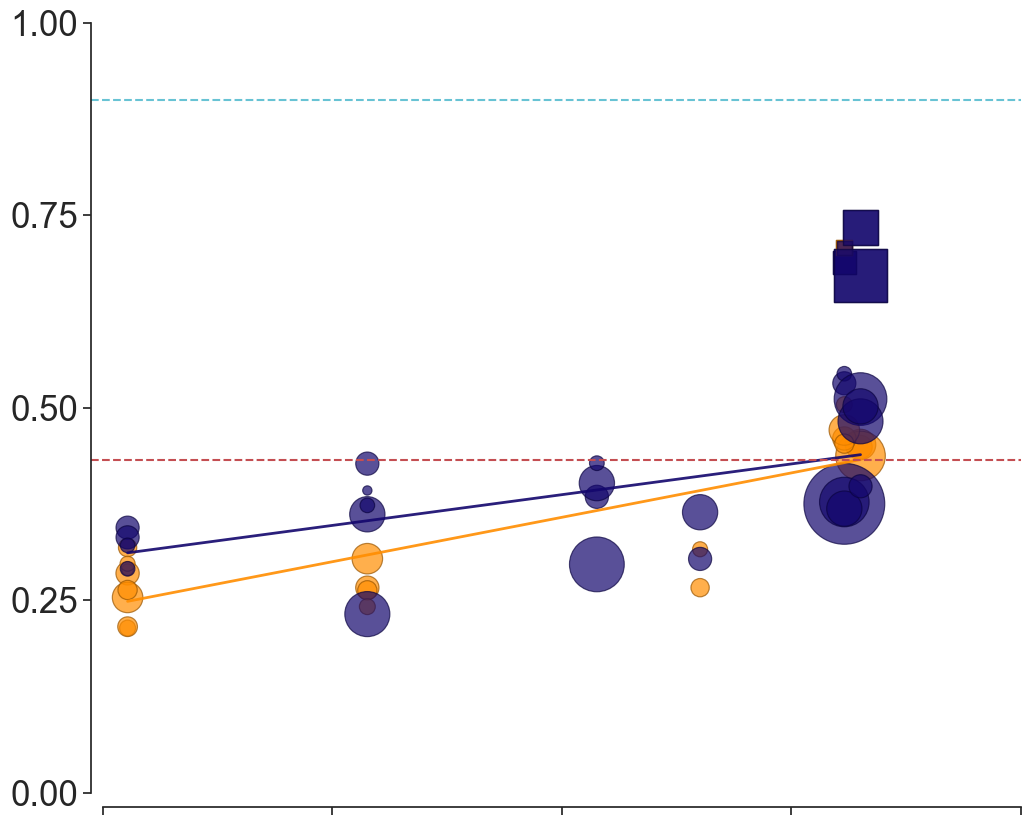

In [25]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

symbolic_corr = 0.432
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

palette = {

    ('cnn'): '#ff8d00',
    ('vit'): '#13066d',  
 
}
chosen_power = 2/3 

df_plot['color'] = df_plot.apply(lambda row: palette[(row['backbone'])], axis=1)
df_plot['edge_color']  = [adjust_lightness(color, 0.6) for color in list(df_plot['color'])]

scale_factor = 700
# Plotting with custom colors
sns.set(style='white')
fig, ax = plt.subplots(figsize= (12, 10))
for (train), group_data in df_plot.groupby(['backbone']):
    sns.scatterplot(
        data=group_data,
        x='train_set_size',
        y='r_distraction',
        color=group_data['color'].iloc[0],
        edgecolor=group_data['edge_color'].iloc[0],
        s=group_data['power_number_parameters'] /scale_factor,  # Size proportional to number_parameters
        alpha=0.7,
        legend=False
    )
for backbone, group_data in df_plot.groupby("backbone"):
    # Log-transform X
    X = np.log10(group_data["train_set_size"]).values.reshape(-1, 1)
    y = group_data["r_distraction"].values

    # Fit regression
    reg = LinearRegression().fit(X, y)

    # Make smooth prediction line
    x_range = np.linspace(group_data["train_set_size"].min(),
                          group_data["train_set_size"].max(), 200)
    x_range_log = np.log10(x_range).reshape(-1, 1)
    y_pred = reg.predict(x_range_log)

    # Plot regression line with the same color as the scatter
    ax.plot(
        x_range,
        y_pred,
        color=palette[backbone],
        linewidth=2,
        linestyle="-",
        alpha=0.9,
    )
    df_distra_MDL = pd.read_csv('distra_MDL.csv')
    top5_distra = df_distra_MDL

    # Merge with df_plot to get their metadata (color, size, backbone, etc.)
    top5_plot = df_plot[df_plot['model'].isin(top5_distra['model'])].copy()
    top5_plot = top5_plot.merge(
        top5_distra[['model', 'r_both']],
        on='model',
        how='left'
    )

    # Plot as squares
    ax.scatter(
        x=top5_plot["train_set_size"],
        y=top5_plot["r_both"],
        s=top5_plot["power_number_parameters"] / scale_factor,
        c=top5_plot["color"],
        edgecolors=top5_plot["edge_color"],
        marker="s",  # square
        alpha=0.7,
        zorder=3
    )
# size_legend_params = [30_000_000, 150_000_000, 1_000_000_000]  # adjust based on your actual model sizes
# size_legend_dots = [np.power(s, chosen_power)/scale_factor for s in size_legend_params]

# legend_elements = [
#     plt.scatter([], [], s=size, color='gray', alpha=0.5, edgecolors='none',
#                 label=f'{p/1e9:.1f}B params' if p >= 1e9 else f'{int(p/1e6)}M params')
#     for size, p in zip(size_legend_dots, size_legend_params)
# ]

# # Place the legend
# ax.legend(
#     handles=legend_elements,
#     title='Model size',
#     loc='lower right',
#     fontsize=25,
#     title_fontsize=25,
#     handleheight=2,
#     labelspacing=1.5,
#     frameon=False
# )
handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticks([1e6, 1e7, 1e8, 1e9,1e10])
yticks = ax.get_yticklabels()
xticks = ax.get_xticklabels()
noise_ceiling = 0.90
plt.axhline(y=symbolic_corr, color='r', linestyle='--',)
plt.axhline(y=noise_ceiling, color='#68C3D4', linestyle='--',)

ax.spines['bottom'].set_position(('outward', 10))  

ax.set_ylabel("")
ax.set_xlabel("")

ax.set_yticklabels(yticks, size=25)
ax.set_xticklabels([], size=25)

ax.spines['left'].set_bounds(0, 1)
ax.spines['bottom'].set_bounds(1e6, 1e10)
ax.tick_params(left=True, bottom=True)


sns.despine()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/figure_mdl.svg', format='svg')

In [29]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']
target = 'r_distraction'
# df_plot = pd.read_csv('all_cors.csv')
conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
# One-hot encode categorical variables: backbone and training_method
df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    drop_first=True
)

# Standardize numerical features
scaler = StandardScaler()
df_features[['number_parameters', 'train_set_size']] = scaler.fit_transform(
    df_features[['number_parameters', 'train_set_size']]
)

X = df_features
y = df_plot[target]

color_significant = '#5A509B'
color_non_significant = '#888'

# Fit Ridge regression
model = Ridge(alpha=1e-2).fit(X, y)
print(model.score(X, y))


0.7303462949831694


In [30]:
def grouped_permutation_importance(model, X, y, groups, n_repeats=30, random_state=0):
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    n_groups = len(groups)

    importances = {}

    for group in groups:
        print(group)
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # permute all columns in this group together
            idx = rng.permutation(len(X))
            X_permuted[group] = X_permuted[group].iloc[idx].values
            scores.append(model.score(X_permuted, y))

        scores = np.array([float(s) for s in scores])
        drops = baseline_score - scores
        mean_drop = np.mean(drops)
        std_drop = np.std(drops)


        m = len(groups)  # number of features
        alpha = 0.05

        # Bonferroni-adjusted z threshold
        z_adj = norm.ppf(1 - alpha / (2*m))
      
        significant = abs(mean_drop) > z_adj * std_drop

        importances[group[0]] = {'mean': mean_drop, 'std': std_drop, 'significant':significant}
       
    return importances



# Example: group dummies for training_method
groups = [
    [col for col in X.columns if col.startswith("training_method_")],
    [col for col in X.columns if col.startswith("backbone_")],
    ['number_parameters'],
    ['train_set_size']
]

importances = grouped_permutation_importance(model, X, y, groups)
feature_importance = pd.DataFrame(importances)
print(feature_importance)
feature_importance2 = feature_importance.T
# Assign colors
feature_importance2['Color'] = feature_importance2['significant'].map(
    {True: color_significant, False: color_non_significant}
)
feature_importance2['Feature'] = feature_importance2.index
feature_importance2.reset_index()

print(feature_importance2)
feature_importance2
feature_importance2.to_csv('temp.csv')

['training_method_supervised', 'training_method_unsupervised']
['backbone_vit']
['number_parameters']
['train_set_size']
            training_method_supervised backbone_vit number_parameters  \
mean                          0.037022      0.17479          0.095963   
std                           0.022224     0.050659          0.046543   
significant                      False         True             False   

            train_set_size  
mean              1.454749  
std               0.224766  
significant           True  
                                mean       std significant    Color  \
training_method_supervised  0.037022  0.022224       False     #888   
backbone_vit                 0.17479  0.050659        True  #5A509B   
number_parameters           0.095963  0.046543       False     #888   
train_set_size              1.454749  0.224766        True  #5A509B   

                                               Feature  
training_method_supervised  training_method_supervised  


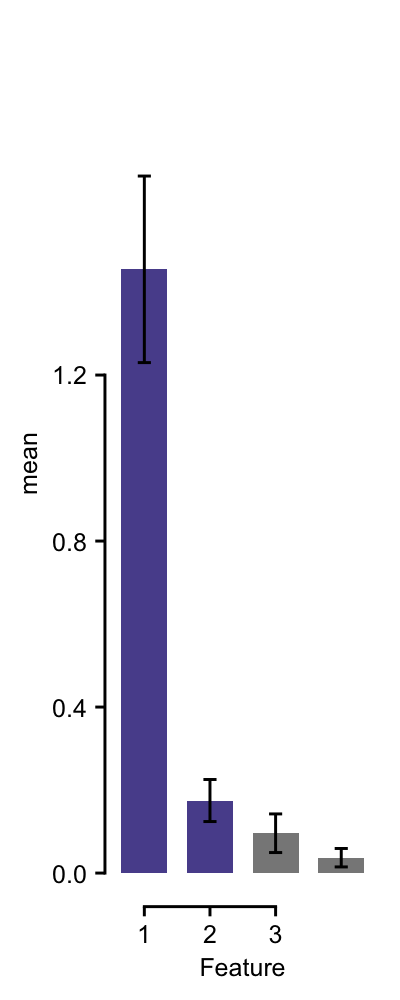

In [31]:
%%R -w 2 -h 5  --units in -r 200

feature_importance <- read.csv('temp.csv')
feature_importance <- feature_importance %>%
  arrange(desc(mean))

feature_importance$Feature <- factor(feature_importance$Feature, levels = feature_importance$Feature)

# Create the ggplot2 bar plot
p <- ggplot(feature_importance, aes(x = Feature, y = mean, fill = Color)) +
    geom_col(width = 0.7) + # geom_col for pre-computed heights, width adjusts bar thickness
    geom_errorbar(
      aes(ymin = mean - std, ymax = mean + std),
      width = 0.2, # Adjust the width of the error bar caps
      color = "black" # Color of the error bars
    ) +
    
    scale_fill_identity() + # Use the 'Color' column directly for fill
    # Customizing the theme for a "prettier" look and removing top/right spines
    # theme_minimal() + # Start with a minimal theme
    theme(
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      panel.background = element_blank(), 
      panel.grid.major.y = element_blank(),

    ) +
    # Set y-axis limits and breaks similar to your Python code
    # The Python y-axis was inverted, but for means, a standard positive up is usually preferred.
    # If you truly want to invert, you'd use scale_y_reverse().
  

    guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=3, breaks=seq(1,3,1)),
          y = guide_axis_manual(trunc_lower=0, trunc_upper=1.2, breaks=seq(0,1.2,0.4))) +


    coord_cartesian(ylim = c(min(feature_importance$mean - feature_importance$std) * 1.1,
                            max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5)
                    )  # This helps control the visible range without dropping data
  
ggsave("plots/feature_importance.svg", p, device='svg',width = 2, height = 5, units = "in")
p

In [11]:
%%R -w 2 -h 4  --units in -r 200

df <- read.csv("all_cors.csv")
df <- na.omit(df[, c("r_distraction","train_set_size","number_parameters","backbone","training_method")])

df$log_train_set_size <- log(df$train_set_size)
df$log_number_parameters <- log(df$number_parameters)

# Random intercepts 
m1 <- lmer(r_distraction ~ log_train_set_size + log_number_parameters +
             (1|training_method) + (1|backbone),
           data=df, REML=TRUE)
print(summary(m1))

# Random intercepts and random slopes for dataset size by training_method and backbone
m2 <- lmer(r_distraction ~ log_train_set_size + log_number_parameters +
             (1 + log_train_set_size|training_method) + (1 |backbone),
           data=df, REML=TRUE)

# Compare models with max likelihood
m1_ml <- update(m1, REML=FALSE)
m2_ml <- update(m2, REML=FALSE)
anova(m1_ml, m2_ml)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: r_distraction ~ log_train_set_size + log_number_parameters +  
    (1 | training_method) + (1 | backbone)
   Data: df

REML criterion at convergence: -104.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3241 -0.7397  0.2092  0.6707  1.4728 

Random effects:
 Groups          Name        Variance  Std.Dev. 
 training_method (Intercept) 3.180e-18 1.783e-09
 backbone        (Intercept) 6.695e-04 2.587e-02
 Residual                    3.351e-03 5.789e-02
Number of obs: 45, groups:  training_method, 3; backbone, 2

Fixed effects:
                       Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)            0.178043   0.117701 41.205903   1.513   0.1380    
log_train_set_size     0.024455   0.003230 41.063393   7.571 2.58e-09 ***
log_number_parameters -0.013953   0.006932 41.677135  -2.013   0.0506 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 

boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')


# Layerwise analysis

In [32]:
base_dir = os.path.join(directory, 'RDMs/dinov3_large')
r_distractions = []

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))


rs = [get_rs(pd.read_csv(f, index_col=0))[0] for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths]


rs = rs[:-1]
layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]

df_original = pd.DataFrame({'layer': layers, 'correlation': rs})

   
            

In [33]:
base_dir = os.path.join(directory, 'RDMs/vit_giant_patch14_clip_224.laion2b')
r_distractions = []

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))


rs = [get_rs(pd.read_csv(f, index_col=0))[0] for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths]



layers = [(i)/(len(layers)-1) for i in layers]

df_2 = pd.DataFrame({'layer': layers, 'correlation': rs})

   
            

In [34]:
base_dir = os.path.join(directory, 'RDMs/convnext_xxlarge.clip_laion2b_soup')
r_distractions = []

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))


rs = [get_rs(pd.read_csv(f, index_col=0))[0] for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths]



layers = [(i)/(len(layers)-1) for i in layers]

df_3 = pd.DataFrame({'layer': layers, 'correlation': rs})

   
            

/var/folders/yr/1hvrtjdn3hzc_7rf_6kpdl69v063g3/T/ipykernel_10823/3326189781.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


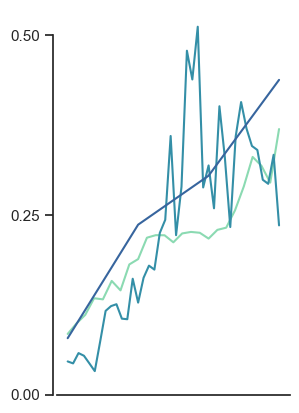

In [35]:
fig, ax = plt.subplots(figsize=(3, 5))
palette = sns.color_palette("mako_r", as_cmap=False)

models = ['dinov3_large', 'vit_clip_giant_laion2b', 'convnext_xxlarge_clip_laion2b']


sns.lineplot(data=df_original, y='correlation', x='layer', color=palette[0])

sns.lineplot(data=df_2, y='correlation', x='layer', color=palette[2])

sns.lineplot(data=df_3, y='correlation', x='layer', color=palette[3])

# sns.lineplot(data=df_4, y='correlation', x='layer', color=palette[4])

ax.set_yticks([0, 0.25, 0.5])
# ax.set_xticks([i for i in range(13)])


yticks = ax.get_yticklabels()
# xticks = ax.get_xticklabels()


ax.set_ylabel("")
# ax.set_xlabel("")

ax.set_yticklabels(yticks, size=12)
# ax.set_xticklabels(xticks, size=12)
ax.spines['left'].set_bounds(0, 0.5)
# ax.spines['bottom'].set_bounds(0, 12)
ax.tick_params(left=True, bottom=False)

# ax.spines['bottom'].set_position(('outward', 5))  # shift outward by 10 points
ax.get_xaxis().set_visible(False)   


ax.spines['left'].set_position(('outward', 3))  

plt.legend().remove()
sns.despine()
# plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/corr_layers.svg', format='svg')

# Testing by adding all layers of a model

In [36]:
def get_rs_2(model, averaged_df=averaged_df):

    base_dir = os.path.join(directory, f'RDMs/{model}')

    # Store paths to layer files to process them once
    layer_file_paths = []
    if os.path.isdir(base_dir):
        layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
        for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
            layer_file_paths.append(os.path.join(base_dir, layer_file))
    results_dict = {}
    for l,layer_file in enumerate(layer_file_paths):
        dists = pd.read_csv(layer_file, index_col=0)
        cumulative_distraction = []
        choice_times = []
        greys = []
        refs = []
        costs = []
        for i in range(len(averaged_df)):
            distractors = averaged_df.iloc[i].distractors.split(',')
            cost = int((averaged_df.iloc[i].reference.split('/')[2]).split('-')[1])
            ref = averaged_df.iloc[i].reference.split('/')[3].split('.png')[0]
            others = [name.split('/')[3].split('.png')[0] for name in distractors]
            others.remove(ref)
            distances = dists.loc[ref, others].values
            if 0 in distances:
                print(distractors)
                break
            difficulty = np.sum(1/np.array(distances))
            # print(dists)
            # print(ref)
            # print(distractors)
            costs.append(cost)
            cumulative_distraction.append(difficulty)
            choice_times.append(averaged_df.iloc[i].choice_time)
            greys.append(averaged_df.iloc[i].greys)
            refs.append(ref)
        results_dict[f'cumulative_distraction_layer{l}'] = cumulative_distraction
  

    results_dict['reference']=refs
    results_dict['choice_time']=choice_times
    results_dict['costs']=costs
    results_dict['grey_level']=greys
    results = pd.DataFrame(results_dict)
    results_grouped = results.groupby('reference').mean()

    X1 = results_grouped['grey_level'].to_numpy()
    # .fit_transform(results_grouped[['grey_level']])
    X2 = results_grouped.filter(like='cumulative_distraction')
    X2 = X2.apply(pd.to_numeric, errors='coerce').to_numpy()


    X4 = results_grouped.filter(like='cumulative_distraction')
    X4 = pd.concat([X4, results_grouped[['costs']]], axis=1)
    X4 = X4.apply(pd.to_numeric, errors='coerce').to_numpy()


    # .fit_transform(results_grouped[['distances']])
    y1 = results_grouped['choice_time'].to_numpy()
    # .fit_transform(results_grouped['choice_time'])

    # Get residuals from choice time by grey level
    lin_model1 = sm.OLS(y1, sm.add_constant(X1)).fit()
    res = lin_model1.resid
 

    # Fit the models on the residuals
    lin_model4 = sm.OLS(res, sm.add_constant(X4)).fit()
    r_both = np.sqrt(lin_model4.rsquared)

    lin_model2 = sm.OLS(res, sm.add_constant(X2)).fit()
    r_distraction = np.sqrt(lin_model2.rsquared)
    # lin_model4 = sm.OLS(res, sm.add_constant(X4)).fit()

    
    # r_MDL, _ = pearsonr(X4, res)

    return r_distraction, r_both



In [37]:
get_rs_2(model='dinov3_small')

(np.float64(0.7319313856037852), np.float64(0.8094277920429305))

# Noise ceiling

In [38]:
folder = 'language_shapes'
files = os.listdir(folder)
dataframes = []

for file in files:
    df = pd.read_csv(os.path.join(folder, file))
    dataframes.append(df)

raw = pd.concat(dataframes, ignore_index=True)
filtered_raw = raw[raw['trial_type'] == 'oddball-grid-img'].copy()
greys = pd.read_csv('language_shapes_greys.csv')

filtered_raw = pd.merge(filtered_raw.copy(), greys)
averaged_df = filtered_raw.groupby(['reference','distractors']).agg({'choice_time':'mean', 'greys':'mean'}).reset_index()
averaged_df = averaged_df[~averaged_df['reference'].str.startswith('./stimuli_train', na=False)]

In [40]:
# Merge grey levels into trial data
filtered_raw = pd.merge(filtered_raw.copy(), greys)

# function to compute difficulty estimates (averaged_df -> difficulty per reference)
def compute_difficulty(df):
    averaged_df = df.groupby(['reference','distractors']).agg(
        {'choice_time':'mean', 'greys':'mean'}).reset_index()
    averaged_df = averaged_df[~averaged_df['reference'].str.startswith('./stimuli_train', na=False)]

    cumulative_distraction = []
    choice_times = []
    refs = []
    greys_list = []

    for i in range(len(averaged_df)):
        distractors = averaged_df.iloc[i].distractors.split(',')
        ref = averaged_df.iloc[i].reference.split('/')[3].split('.png')[0]
        refs.append(ref)
        cumulative_distraction.append(averaged_df.iloc[i].choice_time)  # here just choice time
        choice_times.append(averaged_df.iloc[i].choice_time)
        greys_list.append(averaged_df.iloc[i].greys)

    results = pd.DataFrame({
        'reference': refs,
        'choice_time': choice_times,
        'grey_level': greys_list
    })

    return results.groupby('reference').mean()


In [41]:
# compute noise ceiling
n_iter = 100
correlations = []

participants = filtered_raw['ID'].unique()

for i in range(n_iter):
    np.random.shuffle(participants)
    half = len(participants) // 2
    group1 = participants[:half]
    group2 = participants[half:]

    df1 = filtered_raw[filtered_raw['ID'].isin(group1)]
    df2 = filtered_raw[filtered_raw['ID'].isin(group2)]

    # get per-stimulus difficulty estimates
    diff1 = compute_difficulty(df1)
    diff2 = compute_difficulty(df2)

    # align references
    merged = pd.merge(diff1, diff2, on='reference', suffixes=('_g1', '_g2'))

    # regress out greyscale from choice time in each group
    lin_model1 = sm.OLS(merged['choice_time_g1'], sm.add_constant(merged['grey_level_g1'])).fit()
    res1 = lin_model1.resid

    lin_model2 = sm.OLS(merged['choice_time_g2'], sm.add_constant(merged['grey_level_g2'])).fit()
    res2 = lin_model2.resid

    # correlation across groups = noise ceiling sample
    r, _ = pearsonr(res1, res2)
    correlations.append(r)

noise_ceiling_mean = np.mean(correlations)
noise_ceiling_std = np.std(correlations)

print(f"Noise ceiling: {noise_ceiling_mean:.3f} ± {noise_ceiling_std:.3f}")

Noise ceiling: 0.902 ± 0.025
